In [3]:
!pip install category_encoders

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

from category_encoders import TargetEncoder

In [5]:
df = pd.read_csv("/content/used_cars.csv")

In [6]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [8]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [9]:
df['milage'].unique()

array(['51,000 mi.', '34,742 mi.', '22,372 mi.', ..., '53,705 mi.',
       '714 mi.', '2,116 mi.'], dtype=object)

In [10]:
df1 = df.copy()

In [11]:
df1["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(int)
)

In [12]:
df1["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [13]:
df1["clean_title"] = df1["clean_title"].fillna("No")

In [14]:
categorical_columns = ["fuel_type", "accident"]

for col in categorical_columns:
    df1[col] = df1[col].fillna("Unknown")

In [15]:
df1["accident"] = (
    df1["accident"]
    .str.contains("accident", case=False, na=False)
    .astype(int)
)

In [16]:
CURRENT_YEAR = 2026

df1["vehicle_age"] = CURRENT_YEAR - df1["model_year"]

In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   int64 
 4   fuel_type     4009 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      4009 non-null   int64 
 10  clean_title   4009 non-null   object
 11  price         4009 non-null   int64 
 12  vehicle_age   4009 non-null   int64 
dtypes: int64(5), object(8)
memory usage: 407.3+ KB


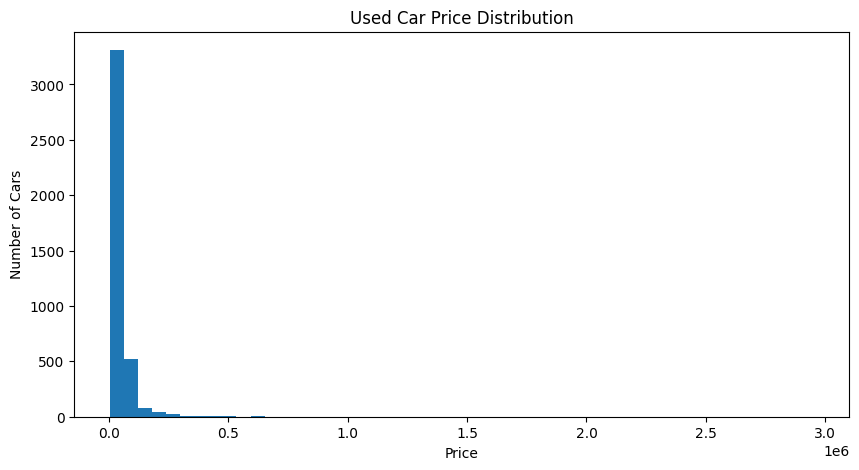

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(df1["price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Used Car Price Distribution")

plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7b108627a360>,
 'caps': [<matplotlib.lines.Line2D at 0x7b108627a9f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b1083d398b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b108627afc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b108627b2c0>],
 'means': []}

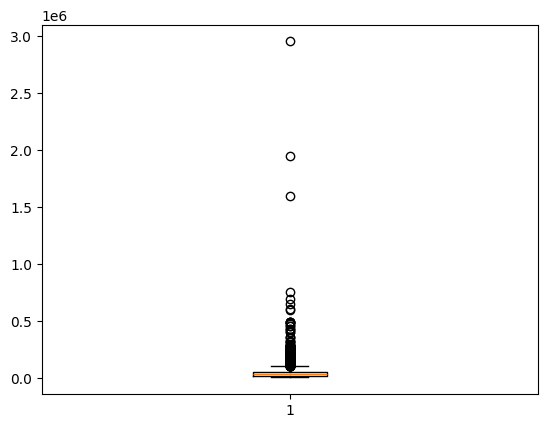

In [19]:
plt.boxplot(df1["price"])

In [20]:
df1=df1[df1['price']<100000]

In [21]:
df1["accident"].value_counts()

,count
accident,
0,2796
1,978


In [22]:
df1['ext_col'].value_counts()

,count
ext_col,
Black,859
White,780
Gray,464
Silver,365
Blue,337
...,...
Verde,1
Super White,1
Midnight Blue Metallic,1


In [23]:
ext_col_stats = df1.ext_col.value_counts(ascending=False)
ext_col_less_than_10 = ext_col_stats[ext_col_stats <=10]
df1.ext_col=df1.ext_col.apply(lambda x: 'other' if x in ext_col_less_than_10 else x)
df1.ext_col.nunique()

17

In [24]:
df1['int_col'].value_counts()

,count
int_col,
Black,1912
Beige,524
Gray,461
Brown,148
–,119
...,...
Gray w/Blue Bolsters,1
Very Light Cashmere,1
Black / Gray,1


In [25]:
int_col_stats = df1.int_col.value_counts(ascending=False)
int_col_less_than_10 = int_col_stats[int_col_stats <=10]
df1.int_col=df1.int_col.apply(lambda x: 'other' if x in int_col_less_than_10 else x)
df1.int_col.nunique()

15

In [26]:
df1['brand'].value_counts()

,count
brand,
Ford,384
BMW,364
Chevrolet,289
Mercedes-Benz,279
Toyota,199
Audi,189
Lexus,159
Porsche,148
Jeep,143


In [27]:
brand_stats = df1.brand.value_counts(ascending=False)
brand_less_than_10 = brand_stats[brand_stats <=10]
df1.brand=df1.brand.apply(lambda x: 'other' if x in brand_less_than_10 else x)
df1.brand.nunique()

39

In [28]:
df1['model'].value_counts()

,count
model,
M3 Base,30
F-150 XLT,24
Corvette Base,22
1500 Laramie,18
Camaro 2SS,17
...,...
Mazda6 Signature,1
SLK-Class SLK320,1
Protege DX,1


In [29]:
model_stats = df1.model.value_counts(ascending=False)
model_less_than_10 = model_stats[model_stats <=10]
df1.model=df1.model.apply(lambda x: 'other' if x in model_less_than_10 else x)
df1.model.nunique()

26

In [30]:
df1.rename(columns={"milage": "mileage"}, inplace=True)

In [31]:
df1["mileage_per_year"] = df1["mileage"] / df1["vehicle_age"].replace(0, 1)

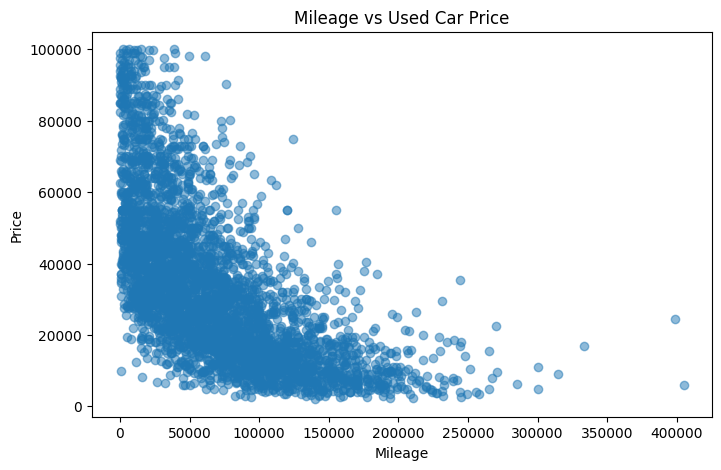

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(df1["mileage"], df1["price"], alpha=.5)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Used Car Price")

plt.show()

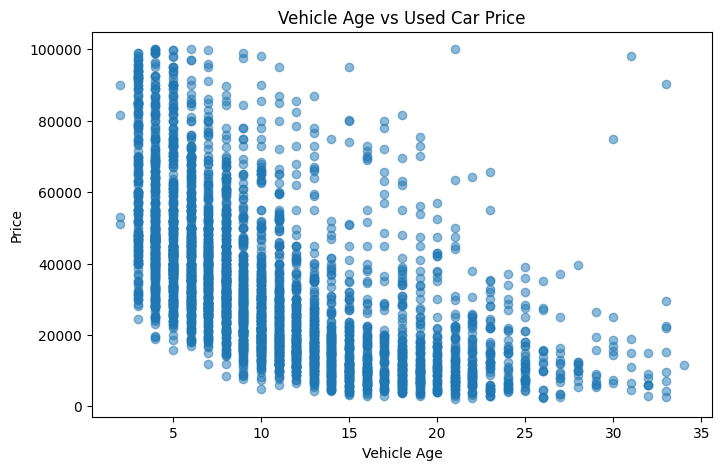

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(df1["vehicle_age"], df1["price"], alpha=0.5)

plt.xlabel("Vehicle Age")
plt.ylabel("Price")
plt.title("Vehicle Age vs Used Car Price")

plt.show()

In [34]:
brand_prices = (df1.groupby("brand")["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False))

brand_prices.head(15)

,mean,median,count
brand,,,
Rivian,93138.176471,93500.0,17
Bentley,59660.615385,59400.0,13
Porsche,50611.601351,49245.0,148
Tesla,48439.471264,45999.0,87
Genesis,43279.900000,43174.5,20
RAM,43029.164835,43449.0,91
Land,42901.271930,38499.5,114
Maserati,39397.433333,36950.0,30
BMW,38649.519231,32000.0,364


In [35]:
corr = df1.select_dtypes("number").corr()
corr.style.background_gradient(axis=None)

,model_year,mileage,accident,price,vehicle_age,mileage_per_year
model_year,1.000000,-0.614184,-0.179452,0.588316,-1.000000,-0.042643
mileage,-0.614184,1.000000,0.280840,-0.636421,0.614184,0.727462
accident,-0.179452,0.280840,1.000000,-0.234979,0.179452,0.196939
price,0.588316,-0.636421,-0.234979,1.000000,-0.588316,-0.372283
vehicle_age,-1.000000,0.614184,0.179452,-0.588316,1.000000,0.042643
mileage_per_year,-0.042643,0.727462,0.196939,-0.372283,0.042643,1.000000


In [36]:
X = df1.drop("price", axis=1)
y = df1["price"]

In [37]:
categorical_features = ["brand", "model", "fuel_type", "engine", "transmission", "ext_col", "int_col", "clean_title"]

numerical_features = ["model_year", "mileage", "vehicle_age", "mileage_per_year", "accident"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split ( X, y, test_size=0.20, random_state=42)

In [39]:
encoder = TargetEncoder(cols=categorical_features,smoothing=10)

In [40]:
X_train_encoded = encoder.fit_transform( X_train, y_train)

X_test_encoded = encoder.transform(X_test)

In [41]:
rf_model = RandomForestRegressor( n_estimators=300, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1 )

In [42]:
rf_model.fit( X_train_encoded, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [43]:
rf_predictions = rf_model.predict(X_test_encoded)

In [44]:
rf_mae = mean_absolute_error( y_test, rf_predictions)
print("Random Forest MAE:", rf_mae)

Random Forest MAE: 7735.250463576159


In [45]:
rf_mpe = mean_absolute_percentage_error( y_test, rf_predictions)
print("Random Forest MPE:", rf_mpe)

Random Forest MPE: 0.36805576042961413


In [46]:
rf_r2 = r2_score( y_test, rf_predictions)
print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.7234095868738042


In [47]:
gb_model = GradientBoostingRegressor( n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)

In [48]:
gb_model.fit(
    X_train_encoded,
    y_train
)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42)

In [49]:
gb_predictions = gb_model.predict(X_test_encoded)

In [50]:
gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_mpe = mean_absolute_percentage_error(y_test, gb_predictions)

gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE: ${gb_mae:,.2f}")
print(f"MPE: {gb_mpe:.2%}")
print(f"R² Score: {gb_r2:.4f}")

Gradient Boosting Results
-------------------------
MAE: $7,514.71
MPE: 35.55%
R² Score: 0.7396


In [51]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        rf_mae,
        gb_mae
    ],
    "R2": [
        rf_r2,
        gb_r2
    ]
})

results.sort_values("MAE")

,Model,MAE,R2
1,Gradient Boosting,7514.709889,0.739616
0,Random Forest,7735.250464,0.723410


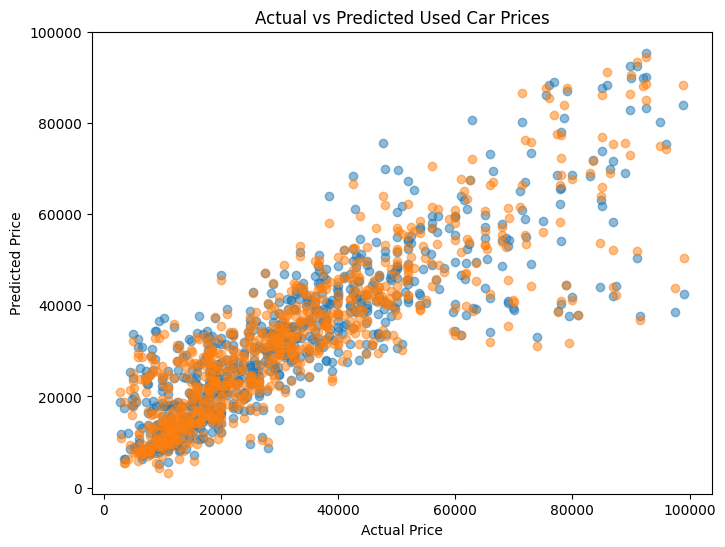

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions, alpha=0.5, label="Random Forest")
plt.scatter(y_test, gb_predictions, alpha=0.5, label="Gradient Boosting")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Used Car Prices")

plt.show()

In [53]:
feature_importance = pd.DataFrame({"Feature": X_train_encoded.columns,"Importance": rf_model.feature_importances_})

feature_importance = feature_importance.sort_values("Importance", ascending=False)

feature_importance.head()

,Feature,Importance
5,engine,0.771365
3,mileage,0.081996
12,mileage_per_year,0.046057
0,brand,0.020758
2,model_year,0.013256


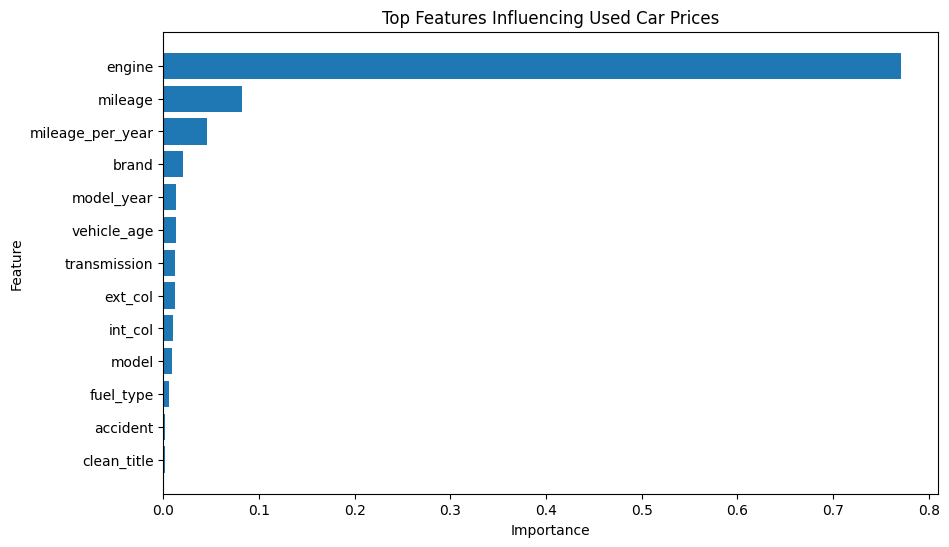

In [54]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Used Car Prices")

plt.gca().invert_yaxis()

plt.show()

In [55]:
def predict_car_price(car_data):

    car_df = pd.DataFrame([car_data])

    car_df["vehicle_age"] = (
        CURRENT_YEAR - car_df["model_year"]
    )

    car_df["mileage_per_year"] = (
        car_df["mileage"] /
        car_df["vehicle_age"].replace(0, 1)
    )

    for col in categorical_features:
        car_df[col] = car_df[col].fillna("Unknown")

    encoded = encoder.transform(car_df)

    prediction = rf_model.predict(encoded)

    return prediction[0]

In [56]:
example_car = {
    "brand": "Toyota",
    "model": "Camry XSE",
    "model_year": 2020,
    "mileage": 35000,
    "fuel_type": "Gasoline",
    "engine": "2.5L I4",
    "transmission": "Automatic",
    "ext_col": "White",
    "int_col": "Black",
    "accident": 0,
    "clean_title": "Yes"
    }

In [57]:
predicted_price = predict_car_price(example_car)

print(f"Estimated Vehicle Price: ${predicted_price:,.2f}")

Estimated Vehicle Price: $37,506.03


In [58]:
import joblib

joblib.dump(rf_model, "used_car_price_model.pkl")

joblib.dump(encoder, "target_encoder.pkl")

['target_encoder.pkl']

In [59]:
from google.colab import files

files.download("used_car_price_model.pkl")
files.download("target_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>